In [1]:
#!!!!!!!!!!!!! ONLY RUN THIS CODE WHEN YOU DON'T HAVE THE CSV !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

from scipy.io import arff
import pandas as pd

# Load the arff file
data, meta = arff.loadarff('fps-in-video-games.arff')

# Convert to a pandas DataFrame
df = pd.DataFrame(data)
# df.to_csv('fps-in-video-games.csv', index=False)

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt






In [3]:

# df = pd.read_csv('fps-in-video-games.csv')
print(df.shape)
df.head()

(425833, 45)


,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,...,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',70.0
1,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',230.0
2,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',250.0
3,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',300.0
4,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,896.0,56.0,61600.0,2080.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',200.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  object 
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  object 
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors     19

In [5]:
# Convert byte to string
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False)


In [6]:
df = df.rename(columns={"GpuBus nterface": "GpuBusInterface"})

In [7]:
missing = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
GpuNumberOfExecutionUnits,412935,96.971113
GpuNumberOfComputeUnits,357107,83.860809
CpuNumberOfTransistors,226039,53.081607
CpuDieSize,202534,47.561838
GpuBandwidth,15441,3.626069
GpuMemorySize,15441,3.626069
GpuMemoryBus,15441,3.626069
GpuNumberOfTransistors,11539,2.709748
GpuDieSize,11196,2.629200
CpuCacheL3,5055,1.187085


In [8]:
cols_to_drop = missing_percent[missing_percent > 10].index
print("Dropped columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Dropped columns: Index(['CpuDieSize', 'CpuNumberOfTransistors', 'GpuNumberOfComputeUnits',
       'GpuNumberOfExecutionUnits'],
      dtype='object')


In [9]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Drop duplicate
df = df.drop_duplicates()

# Drop kolom yang tidak penting (opsional)
df = df.drop(columns=["CpuName", "GpuName"], errors='ignore')

In [11]:
Q1 = df["FPS"].quantile(0.25)
Q3 = df["FPS"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["FPS"] >= Q1 - 1.5*IQR) & (df["FPS"] <= Q3 + 1.5*IQR)]

In [12]:
# check the spread for game name
print(df["GameName"].value_counts())

# Slicing the dataset to only include games with at less than 10000 samples
# df = df[df["GameName"].isin(df["GameName"].value_counts()[df["GameName"].value_counts() < 10000].index)]

GameName
counterStrikeGlobalOffensive    27021
fortnite                        22811
playerUnknownsBattlegrounds     21256
overwatch                       18789
grandTheftAuto5                 17627
leagueOfLegends                 15248
battlefield1                     9681
apexLegends                      8262
dota2                            6783
worldOfTanks                     6541
battlefield4                     5809
minecraft                        4875
callOfDutyBlackOps4              4097
rust                             3119
arkSurvivalEvolved               2915
rocketLeague                     2444
callOfDutyWW2                    1026
pathOfExile                      1026
destiny2                         1026
radicalHeights                   1026
seaOfThieves                     1026
frostpunk                        1026
totalWar3Kingdoms                1026
airMechStrike                    1026
battletech                       1026
farCry5                          1026
rai

In [13]:

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])


In [14]:
X = df.drop("FPS", axis=1)
y = df["FPS"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Before PCA:", X_train_scaled.shape)
print("After PCA :", X_train_pca.shape)

Before PCA: (55110, 38)
After PCA : (55110, 18)


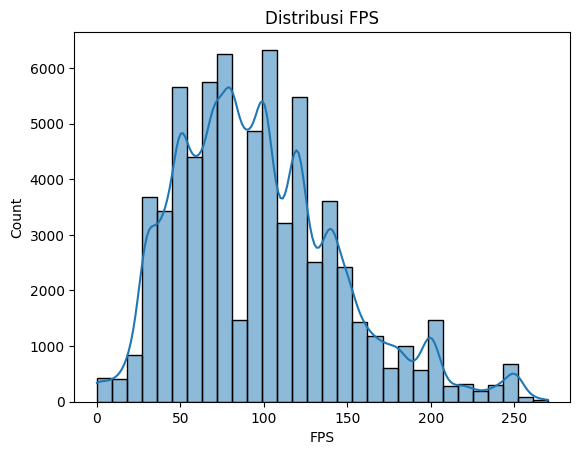

In [15]:
sns.histplot(df["FPS"], bins=30, kde=True)
plt.title("Distribusi FPS")
plt.show()

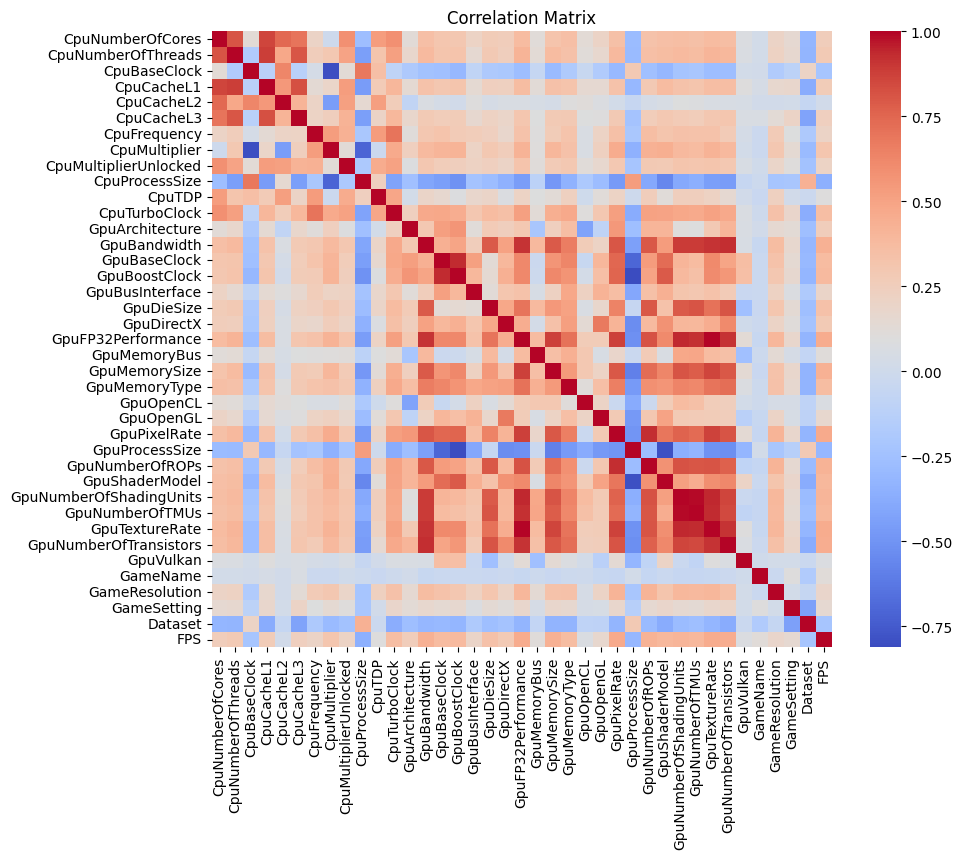

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

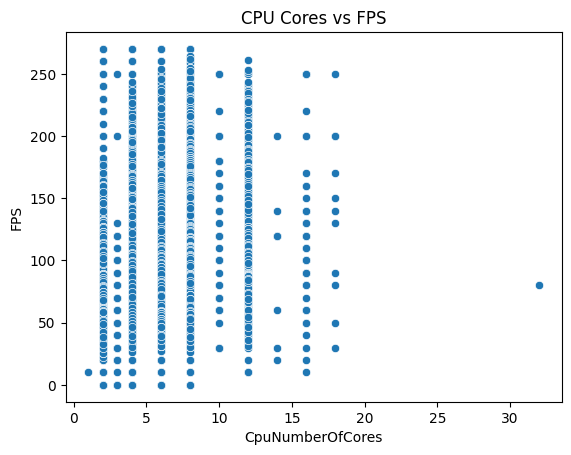

In [17]:
sns.scatterplot(x=df["CpuNumberOfCores"], y=df["FPS"])
plt.title("CPU Cores vs FPS")
plt.show()

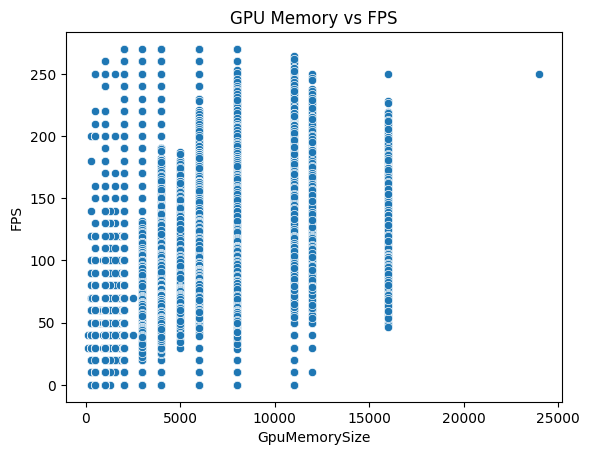

In [18]:
sns.scatterplot(x=df["GpuMemorySize"], y=df["FPS"])
plt.title("GPU Memory vs FPS")
plt.show()

<Axes: xlabel='GameResolution', ylabel='FPS'>

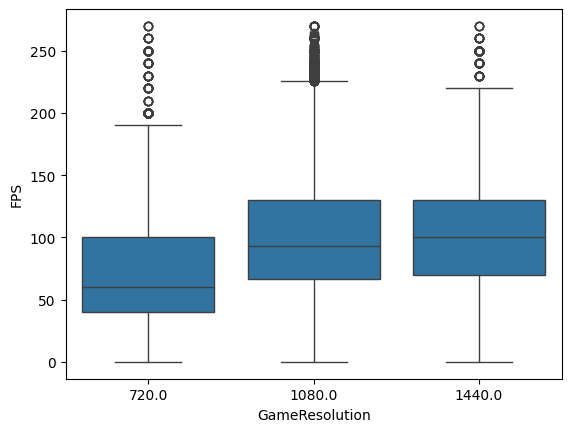

In [19]:
sns.boxplot(x=df["GameResolution"], y=df["FPS"])


In [20]:
def evaluate_model(y_true, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("R2  :", r2_score(y_true, y_pred))

In [21]:
lr = LinearRegression()
lr.fit(X_train_pca, y_train)

y_pred_lr = lr.predict(X_test_pca)


In [22]:

# Input Layer
inputs = keras.Input(shape=(X_train_pca.shape[1],))

# Hidden Layers
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)

# Output Layer
outputs = layers.Dense(1)(x)

# Functional API Model
baseline_model = keras.Model(inputs=inputs, outputs=outputs)

# Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model Summary
print("Baseline ANN Architecture")
baseline_model.summary()

# Train Baseline Model
history_baseline = baseline_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict Baseline
y_pred_baseline = baseline_model.predict(X_test_pca)



Baseline ANN Architecture


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 2716.3735 - mae: 38.4091 - val_loss: 1750.8385 - val_mae: 31.3489
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1662.6364 - mae: 30.9619 - val_loss: 1709.6083 - val_mae: 31.1523
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1632.7612 - mae: 30.6789 - val_loss: 1695.1553 - val_mae: 30.7916
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1614.6271 - mae: 30.5041 - val_loss: 1667.8583 - val_mae: 30.8846
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1599.2085 - mae: 30.3169 - val_loss: 1657.4889 - val_mae: 30.6351
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1581.5917 - mae: 30.1355 - val_loss: 1640.1864 - val_mae: 30.6706
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1562.9193 - mae: 29.9215 - val_loss: 1625.0698 - val_mae: 30.5433
Epoch 8/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1544.5087 - mae: 29.7491 - val_loss: 1612

In [23]:

print("Linear Regression")
evaluate_model(y_test, y_pred_lr)
# Evaluate Baseline
print("\nBaseline ANN Performance")
evaluate_model(y_test, y_pred_baseline)



Linear Regression
RMSE: 41.28929443323183
MAE : 31.568417412652757
R2  : 0.29033366219218537

Baseline ANN Performance
RMSE: 37.426101734678284
MAE : 28.462234289706455
R2  : 0.41691956388209217


In [24]:
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# lr_cv = cross_val_score(lr, X_train_pca, y_train, cv=kf, scoring='r2')

# print("LR CV R2:", lr_cv.mean())


LR CV R2: 0.2847197099866129


In [25]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    num_units = hp.Choice("num_units", [64, 128])
    dropout_rate = hp.Choice("dropout_rate", [0.2, 0.3])
    learning_rate = hp.Choice("learning_rate", [1e-3, 5e-4])

    inputs = keras.Input(shape=(X_train_pca.shape[1],))
    x = layers.Dense(num_units, activation="relu")(inputs)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(num_units // 2, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


tuner = kt.GridSearch(
    build_model,
    objective="val_loss",
    max_trials=16,   # total combinations
    directory="tuning",
    project_name="pca_regression"
)

tuner.search(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=kt.engine.hyperparameters.HyperParameters().Choice(
        "batch_size", [32, 64]
    ),
    verbose=1
)

Trial 8 Complete [00h 01m 37s]
val_loss: 1591.9058837890625

Best val_loss So Far: 1437.643310546875
Total elapsed time: 00h 12m 59s


In [32]:
best_result = tuner.results_summary()
best_result

Results summary
Results in tuning/pca_regression
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 04 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.2
learning_rate: 0.001
Score: 1437.643310546875

Trial 06 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.3
learning_rate: 0.001
Score: 1463.961669921875

Trial 05 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.2
learning_rate: 0.0005
Score: 1495.9896240234375

Trial 00 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.2
learning_rate: 0.001
Score: 1542.0694580078125

Trial 02 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.3
learning_rate: 0.001
Score: 1589.2984619140625

Trial 07 summary
Hyperparameters:
num_units: 128
dropout_rate: 0.3
learning_rate: 0.0005
Score: 1591.9058837890625

Trial 01 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.2
learning_rate: 0.0005
Score: 1635.4652099609375

Trial 03 summary
Hyperparameters:
num_units: 64
dropout_rate: 0.3
learning_rate:

In [31]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Model Summary")
best_model.summary()
print("\nBest Hyperparameters")
print(best_hp.values)


Best Model Summary


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)


Best Hyperparameters
{'num_units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.001}


In [33]:

y_pred_best = best_model.predict(X_test_pca)
print("\nBest ANN Performance")
evaluate_model(y_test, y_pred_best)




431/431 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Best ANN Performance
RMSE: 36.9960050703555
MAE : 27.944642521380203
R2  : 0.43024395330193466
